<h1>Case Study I: Cyprus</h1>
<h3>River Basin covering the full island, Hot Temperate summer dry hot summer (Csa) climate</h3>

<h2>Data Used:</h2>

- Flo1K (Barbarossa et al. 2018): streamflow raster   
- Mindat (Von Bargen et al. 2025): collected from the API in this notebook  
- HydroSHEDS (Lehrer et al. 2008): Flow Direction raster    
- HydroBASINS (Lehner and Grill 2013): Basin vectors    
- Mining polygons (Tang and Werner 2023): Mining area vectors   

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
from data_utils import *
from classes import AMDModel
import contextily as cx
import matplotlib.colors as mcolors
import numpy as np
new_model_initrun = True

<h1>Configuration</h1>

In [2]:
time_first = "1960"
time_last = "2015"
region = "Cyprus"
hydrobasins_region_code = "eu"
basins_iloc = [47, 48]
case_study_nr = "CSIII"
hybas_ids_of_interest = [2040000010]
metre_crs = "EPSG:6312" #(Cyprus)
f = 1

<h2>Collect Mindat data </h2>
<p> Mindat data is used to filter if the mining polygons from Tang and Werner 2023, actually have the mineral of interest. For this case study the mineral is set as pyrite using keyword aguments: <b>material_name: "pyrite", mineral_id: 3314, material_strings: "(Fe|S)</b>.</p>

<p>The region of interest is set to "Spain" through the regular argument: region. </p>

<p> The mindat_collector() function relies on the fact that you have access to the mindat API with an API key saved in the repository. The name of the file can be changed through the keyword argument: <b>mindat_api_str</b>.

In [3]:
mindat_collector(region)

File already exists, delete if you want new data


<h2>Flo1K preperation</h2>
<p>Note that the file input and output locations can be changed through the use of keyword arguments, one especially of note is the <b>date</b> keyword argument which takes a pandas Timestamp object as input, only the year argument of this Timestamp should be changed, while the month and day should stay at 1, as the Flo1K dataset works on yearly data set to <b>year/01/01</b>.</p>

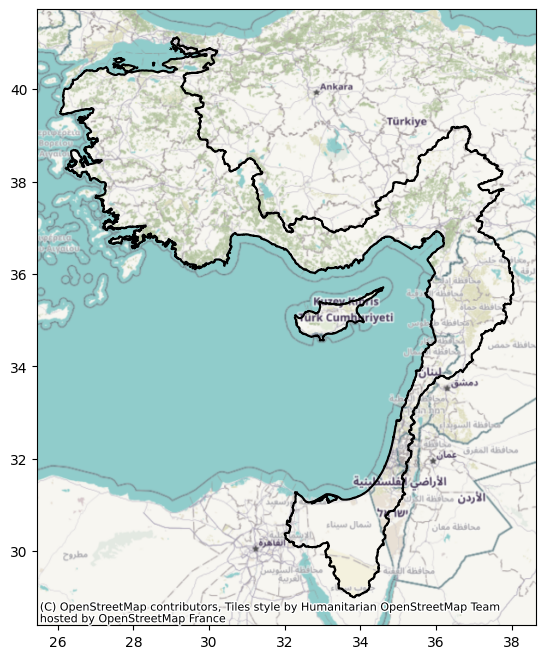

In [4]:
basins = gpd.read_file(f"../data/hybas_{hydrobasins_region_code}_lev04/hybas_{hydrobasins_region_code}_lev04_v1c.shp")

matching_rows = basins[basins["HYBAS_ID"].isin(hybas_ids_of_interest)]
if matching_rows.empty:
    print("No matching HYBAS_ID found.")
    print("Sample HYBAS_ID values:", basins["HYBAS_ID"].head(20).tolist())
    raise ValueError(f"HYBAS_ID not found: {hybas_ids_of_interest}")
iloc_indices = matching_rows.index.tolist()
iloc_tuple = tuple(iloc_indices)
aoi = basins.iloc[iloc_indices[0]:iloc_indices[-1] + 1]
basins_iloc[0] = iloc_indices[0]
basins_iloc[1] = iloc_indices[-1] + 1
aoi = basins.iloc[basins_iloc[0]: basins_iloc[1]]
ax = aoi.boundary.plot(figsize=(8, 8), edgecolor = "k")
cx.add_basemap(ax, crs = aoi.crs)

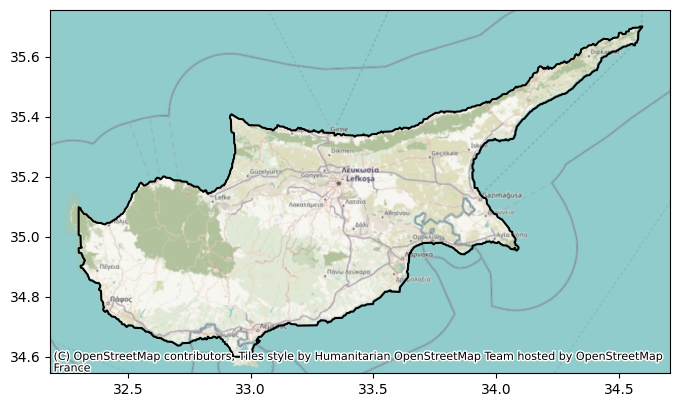

In [5]:
from shapely.geometry import box

# define Cyprus bounding box (minx, miny, maxx, maxy)
cyprus_bbox = box(32.3, 34.6, 34.6, 35.7)

# clip the AOI to Cyprus only
aoi = gpd.clip(aoi, cyprus_bbox)

# re-plot to verify
ax = aoi.boundary.plot(figsize=(8, 8), edgecolor="k")
cx.add_basemap(ax, crs=aoi.crs)
plt.show()

In [6]:
time_array = np.ndarray(2, dtype = "datetime64[D]")
time_array[0] = np.datetime64(f"{time_first}-01-01")
time_array[-1] = np.datetime64(f"{time_last}-01-01")
flo1k_prep(basins_iloc = basins_iloc, date= time_array, output_path=f"../data/flo_{case_study_nr}_", basins_path= f"../data/hybas_{hydrobasins_region_code}_lev04/hybas_{hydrobasins_region_code}_lev04_v1c.shp", aoi = aoi)

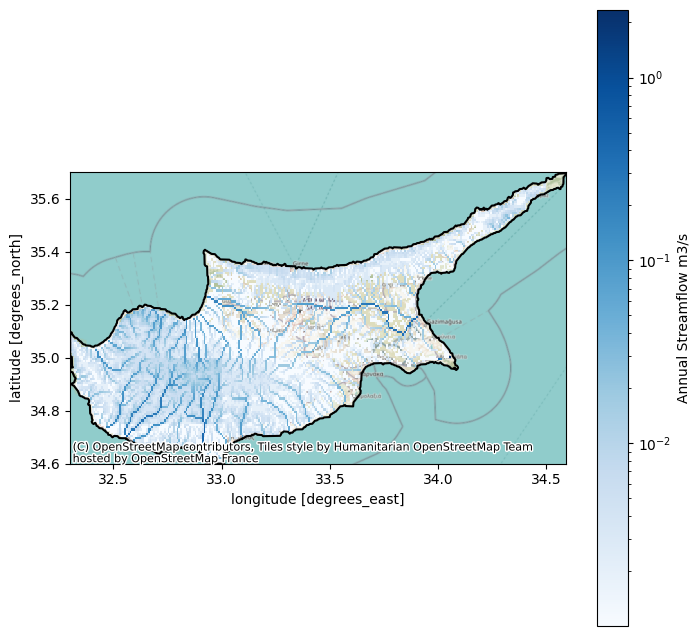

In [7]:
flo_aoi_date = xr.open_dataset(f"../data/flo_{case_study_nr}_{time_first}-{time_last}.nc")
ax = aoi.boundary.plot(figsize=(8, 8), edgecolor = "k")
flo_aoi_date_plot = flo_aoi_date["qav"].where(flo_aoi_date["qav"] > 0)
flo_aoi_date_plot = flo_aoi_date_plot.isel(time = 0)
norm = mcolors.LogNorm(vmin = flo_aoi_date_plot.min(), vmax = flo_aoi_date_plot.max())
flo_aoi_date_plot.plot(ax = ax, cmap = "Blues", norm = norm, cbar_kwargs = {"label": "Annual Streamflow m3/s"})
cx.add_basemap(ax, crs = aoi.crs)
plt.title("");

<h2>Flow Direction</h2>
<p>The model requires each cell in the raster to have an unique cell ID (ID), the IDs of where the flow goes to next (outID), and if the cell is the most upstream (source). To create this the HydroSHEDS hydir data is used </p>

In [8]:
hydir_ds = xr.open_dataset(f"../data/hyd_{hydrobasins_region_code}_dir_30s/hyd_{hydrobasins_region_code}_dir_30s.tif")
hydir_ds = hydir_ds.rename({"band_data": "hydir"})
hydir_ds_ids = hydir_IDs(hydir_ds, aoi)

Grid size: 8640 rows, 11400 cols


c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\xarray\core\duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\xarray\core\duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


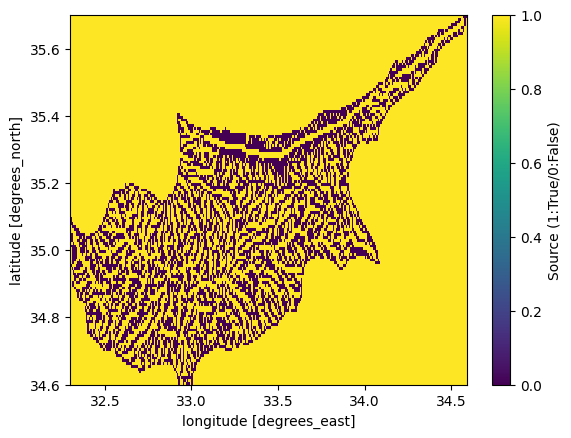

In [9]:
ax = hydir_ds_ids["source"].plot(cbar_kwargs = {"label": "Source (1:True/0:False)"})
plt.title("")
plt.show()
plt.close()

<h2>Mining Polygons and Mineral Occurences</h2>
<p>Because no good dataset exists where mining areas are matched with what ores are present this matching has to be here. The principle is as follows, the mining polygons (Tang and Werner 2013) are first converted to raster datasets (to align with the other datasets) with a bolean array of mine or no mine. The mindat mineral occurences are points on a map, but all have some error associated with them, thus the mineral points get a buffer of around 5km/0.045 degrees. If a mine cell intersects with the buffer of a mineral occurence the mine is kept, if not the mine likely does not have the mineral and is dropped. </p>

In [10]:
vector_rasterisation(flo1k_path=f"../data/flo_{case_study_nr}_{time_first}-{time_last}.nc")

mines_raster = xr.open_dataset("../data/mines_raster.tif")
mineral_points = gpd.read_file(f"../data/mindat_data/{region}_pyrite.csv")
mineral_points = gpd.points_from_xy(mineral_points["longitude"], mineral_points["latitude"], crs = "EPSG:4326")
mineral_points = gpd.GeoDataFrame(mineral_points).set_geometry(col = 0)

filtered_mines_raster = filter_mines_with_buffer(mines_raster, mineral_points, metre_crs)

Raster saved to ../data/mines_raster.tif


<h2>Merging Datasets</h2>
<p>For the model a single dataset is used, thus the different datasets are merged using xarray.merge.</p>   
<p>Note that labels, descriptions and units are changed in the function cleanup_and_metadata() in the funcs file </p>

In [11]:
# convert bools to ints
hydir_ds_ids_num = bool_to_int(hydir_ds_ids.copy())   

# reproject
flo_aoi_date = flo_aoi_date.rio.write_crs("EPSG:4326")
ref = flo_aoi_date

hydir_aligned = hydir_ds_ids_num.rio.reproject_match(ref)
mines_aligned = filtered_mines_raster.rio.reproject_match(ref)

# merge
ds_combined = xr.merge([ref, hydir_aligned, mines_aligned])

# cleanup
ds = cleanup_and_metadata(ds_combined)

C:\Users\luuc_\AppData\Local\Temp\ipykernel_5176\2698492422.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ref, hydir_aligned, mines_aligned])


<h2>Adding Time dimension </h2>
<p>Although the Flo1K dataset already has a time dimension of years 1960-2015, a more discrete timestep is needed for the model, with the function add_time (see funcs.py) this more discrete time dimension is added.</p>

In [12]:
ds = add_time(ds, 52, "W")

<h2>Estimating Ore amounts</h2>
<p>For each cell of "mines", a reactive ore amount must be estimated. This is done using the equation:       


$$
reactive_{ore} = 27000f
$$

In [13]:
ds = estimate_ore(ds, f) 

In [14]:
ds

<xarray.Dataset> Size: 424MB
Dimensions:      (time: 2912, lat: 132, lon: 275)
Coordinates:
  * time         (time) datetime64[ns] 23kB 1960-01-03 1960-01-10 ... 2015-10-18
  * lat          (lat) float64 1kB 34.6 34.61 34.62 34.63 ... 35.68 35.69 35.7
  * lon          (lon) float64 2kB 32.3 32.31 32.32 32.33 ... 34.57 34.58 34.59
    crs          int64 8B 0
    spatial_ref  int64 8B 0
Data variables:
    Q            (time, lat, lon) float32 423MB nan nan nan nan ... nan nan nan
    ID           (lat, lon) int64 290kB -9223372036854775807 ... 66081550
    outID        (lat, lon) int64 290kB -9223372036854775807 ... 66081550
    source       (lat, lon) int16 73kB 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 0 0 0
    ore          (lat, lon) float64 290kB nan nan nan nan ... nan nan nan nan

<h2>Modelling</h2>

In [ ]:
if new_model_initrun:
    model = AMDModel(ds, "week", output_path= f"../data/validation data/AMDFLOW_{case_study_nr}_{time_first}-{time_last}_W.nc",
                     alpha_s = 1e-5, A_s_ratio= 0.5)

In [16]:
if new_model_initrun:
    model.run()

1it [00:00,  7.56it/s]c:\Users\luuc_\Desktop\IE 2025-2026\Thesis\AMDFLOW\classes.py:533: RuntimeWarning: overflow encountered in add
  mol_amount = (self._buffer[var][0] + self._buffer[var][1] + self._sbuffer[var][0] + self._sbuffer[var][1])
c:\Users\luuc_\Desktop\IE 2025-2026\Thesis\AMDFLOW\classes.py:536: RuntimeWarning: overflow encountered in multiply
  concentration_ug_per_L = concentration_mg_per_L * 1000  # µg/L
c:\Users\luuc_\Desktop\IE 2025-2026\Thesis\AMDFLOW\classes.py:539: RuntimeWarning: overflow encountered in add
  h_mol = self._buffer["hydrogen_ion"][0] + self._buffer["hydrogen_ion"][1] + self._sbuffer["hydrogen_ion"][0] + self._sbuffer["hydrogen_ion"][1]
2it [00:00,  8.05it/s]c:\Users\luuc_\Desktop\IE 2025-2026\Thesis\AMDFLOW\classes.py:535: RuntimeWarning: overflow encountered in multiply
  concentration_mg_per_L = concentration_molar * self.molar_masses[var]  # mg/L
3it [00:00,  8.19it/s]c:\Users\luuc_\Desktop\IE 2025-2026\Thesis\AMDFLOW\classes.py:689: RuntimeWarnin

<h2>Validation

In [34]:
output = xr.open_dataset(f"../data/validation data/AMDFLOW_{case_study_nr}_{time_first}-{time_last}_W.nc")

In [35]:
ferric_iron = output["ferric_iron"]
ferrous_iron = output["ferrous_iron"]
sulphate = output["sulphate"]
hydron = output["hydrogen_ion"]
iron_III_hydroxide = output["iron_III_hydroxide"]
ph = output["pH"]
output.close()

In [36]:
validation_ph = pd.read_csv(f"../data/validation data/{case_study_nr}/Metrics_pH.csv").dropna()
display(validation_ph.sort_values("KGE", ascending = False))
try:
    best_nse_ph = validation_ph.sort_values("KGE", ascending = False).iloc[0]
except:
    pass

,wqms_id,n,RMSE,bias,NSE,KGE,R,cell_lat,cell_lon
15,wqms_05400034,58,1.200931,-1.154959,-23.767303,0.204053,-15.923269,34.937500,32.587500
1,wqms_05400003,12,0.956427,-0.905717,-12.153023,0.108580,-21.454039,34.987500,33.404167
5,wqms_05400013,85,1.153450,-1.097159,-10.324469,0.065451,-37.473701,34.895832,32.745834
13,wqms_05400032,21,1.252374,-1.195132,-10.034151,0.027975,-59.000988,34.737500,32.670834
16,wqms_05400035,48,1.031949,-0.908331,-6.057530,0.021209,-9.599846,34.779167,32.854168
3,wqms_05400008,26,1.682011,-1.544349,-15.197172,-0.008525,-8.476833,34.879166,33.337500
11,wqms_05400027,71,1.434990,-1.386643,-16.905283,-0.017904,-58.032970,34.912500,32.987500
9,wqms_05400021,45,0.890042,-0.792723,-6.449904,-0.056367,-13.296133,35.029167,33.320835
6,wqms_05400017,67,1.549788,-1.511898,-22.059453,-0.058972,-105.799141,34.995834,32.895832
10,wqms_05400025,88,1.296603,-1.189317,-8.451695,-0.109314,-20.455458,34.779167,33.104168


In [37]:
validation_fe_dis = pd.read_csv(f"../data/validation data/{case_study_nr}/Metrics_Fe-Dis.csv")
display(validation_fe_dis.sort_values("KGE", ascending = False))
try:
    best_nse_fe_dis = validation_fe_dis.sort_values("KGE", ascending = False).iloc[0]
except:
    pass

,wqms_id,n,RMSE,bias,NSE,KGE,R,cell_lat,cell_lon


In [38]:
validation_fe_tot = pd.read_csv(f"../data/validation data/{case_study_nr}/Metrics_Fe-Tot.csv")
display(validation_fe_tot.sort_values("KGE", ascending = False))
try:
    best_nse_fe_tot = validation_fe_tot.sort_values("KGE", ascending=False).iloc[0]
except:
    pass

,wqms_id,n,RMSE,bias,NSE,KGE,R,cell_lat,cell_lon
0,wqms_05400017,32,87161.829444,62520.695312,-1.049833,-0.552157,-4.126820e+04,35.045834,32.879166
1,wqms_05400018,25,83723.644450,67940.640625,-1.926992,-0.691066,-2.390573e+05,35.045834,32.887500
2,wqms_05400019,28,100857.893216,61682.449219,-0.597641,-0.802842,-1.441609e+07,35.062500,33.012500
3,wqms_05400022,7,85271.558306,32173.281250,-0.166513,-0.900541,-1.705358e+06,34.937500,33.329166


In [39]:
caravan = xr.open_dataset("../data/validation data/Caravan-Qual_lite.zarr", engine="zarr",
                               chunks={})

In [40]:
obs_fe_tot = caravan.sel(wqms_id = best_nse_fe_tot["wqms_id"])["Fe-Tot"]
obs_ph = caravan.sel(wqms_id = best_nse_ph["wqms_id"])["pH"]

In [41]:
model_fe_tot = ferric_iron.sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"]) + \
        ferrous_iron.sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"]) + \
        iron_III_hydroxide.sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"])

model_ph = ph.sel(lat = best_nse_ph["cell_lat"], lon = best_nse_ph["cell_lon"])

C:\Users\luuc_\AppData\Local\Temp\ipykernel_5176\1185575636.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


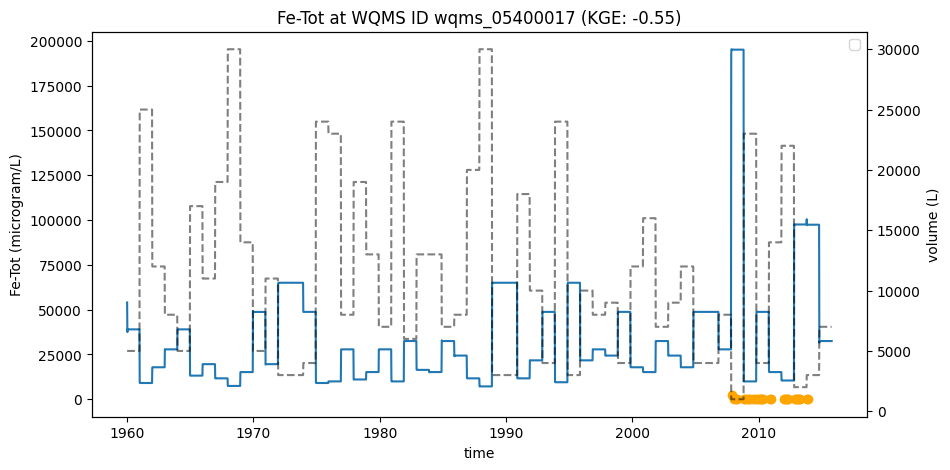

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(obs_fe_tot.time, obs_fe_tot.values, label = "Observed Fe-Tot", marker = "o", color = "orange")
model_fe_tot.plot(ax = ax, label = "Modeled Fe-Tot")
ax.set_title("")
ax2 = ax.twinx()
Q = model.dataset["Q"].sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"], method = "nearest")
volume = Q / model.v * model.dx * 1000
ax2.plot(volume.time, volume.values, linestyle = "--", color = "k", alpha = 0.5)
ax2.set_title("")
ax2.set_ylabel("volume (L)")
plt.legend()
plt.title("")
plt.title(f"Fe-Tot at WQMS ID {best_nse_fe_tot['wqms_id']} (KGE: {best_nse_fe_tot['KGE']:.2f})")
plt.xlabel("Time")
ax.set_ylabel("Fe-Tot (microgram/L)");

C:\Users\luuc_\AppData\Local\Temp\ipykernel_5176\2820551851.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


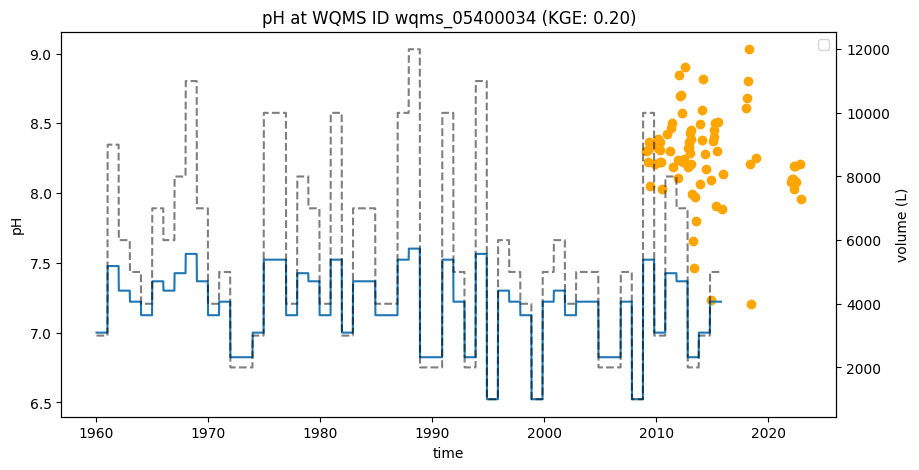

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(obs_ph.time, obs_ph.values, label = "Observed pH", marker = "o", color = "orange")
model_ph.plot(ax = ax, label = "Modeled pH")
ax.set_title("")
ax2 = ax.twinx()
Q = model.dataset["Q"].sel(lat = best_nse_ph["cell_lat"], lon = best_nse_ph["cell_lon"], method = "nearest")
volume = Q / model.v * model.dx * 1000
ax2.plot(volume.time, volume.values, linestyle = "--", color = "k", alpha = 0.5)
ax2.set_title("")
ax2.set_ylabel("volume (L)")
plt.legend()
plt.title(f"pH at WQMS ID {best_nse_ph['wqms_id']} (KGE: {best_nse_ph['KGE']:.2f})")
plt.xlabel("Time")
ax.set_ylabel("pH");

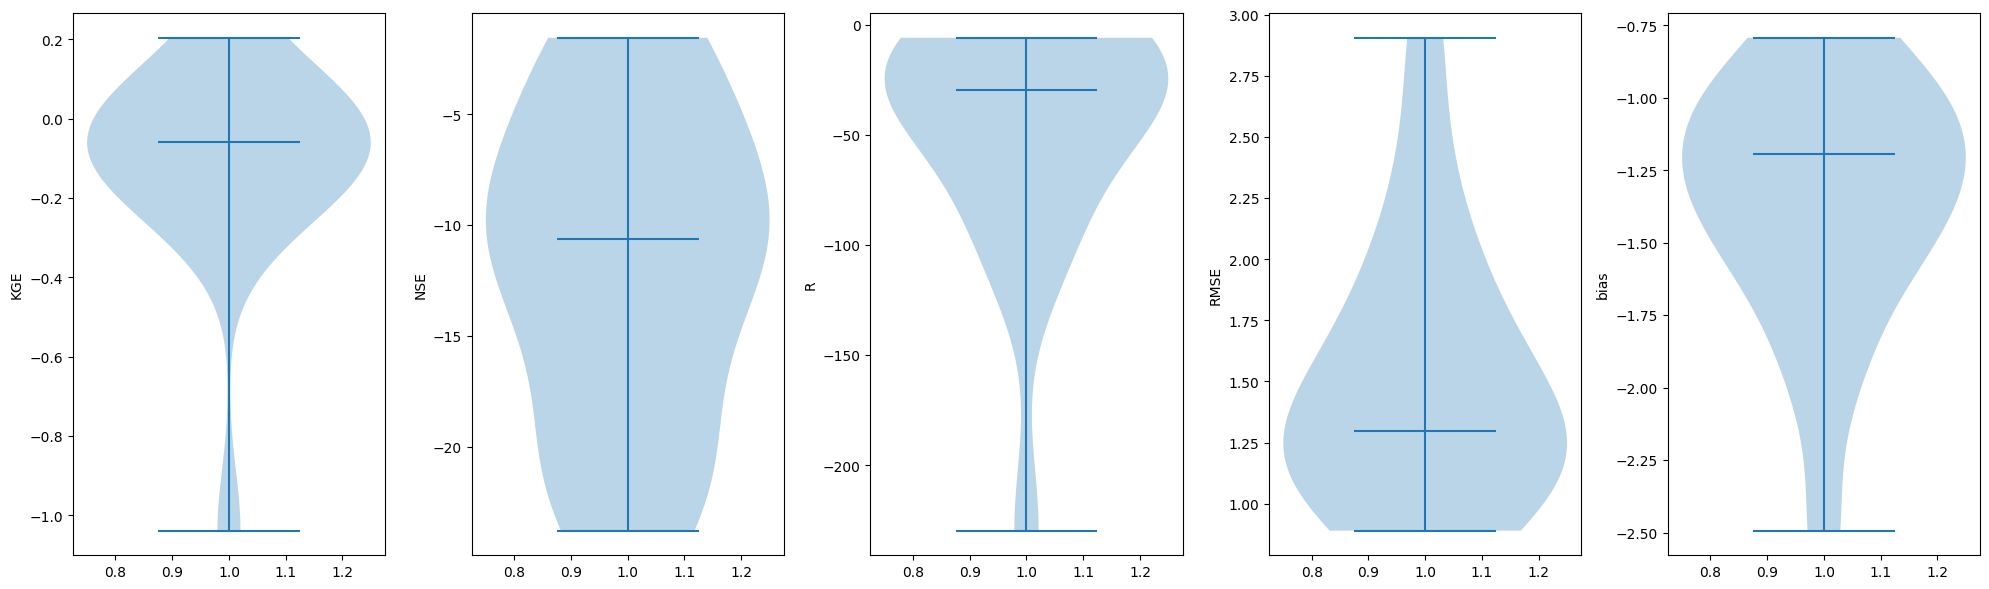

In [44]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(nrows = 1, ncols = 5, figsize = (20, 6))
ax1.violinplot(validation_ph["KGE"], showmedians = True)
ax1.set_ylabel("KGE")
ax2.violinplot(validation_ph["NSE"], showmedians = True)
ax2.set_ylabel("NSE")
ax3.violinplot(validation_ph["R"], showmedians = True)
ax3.set_ylabel("R")
ax4.violinplot(validation_ph["RMSE"], showmedians = True)
ax4.set_ylabel("RMSE")
ax5.violinplot(validation_ph["bias"], showmedians = True)
ax5.set_ylabel("bias")
plt.tight_layout();

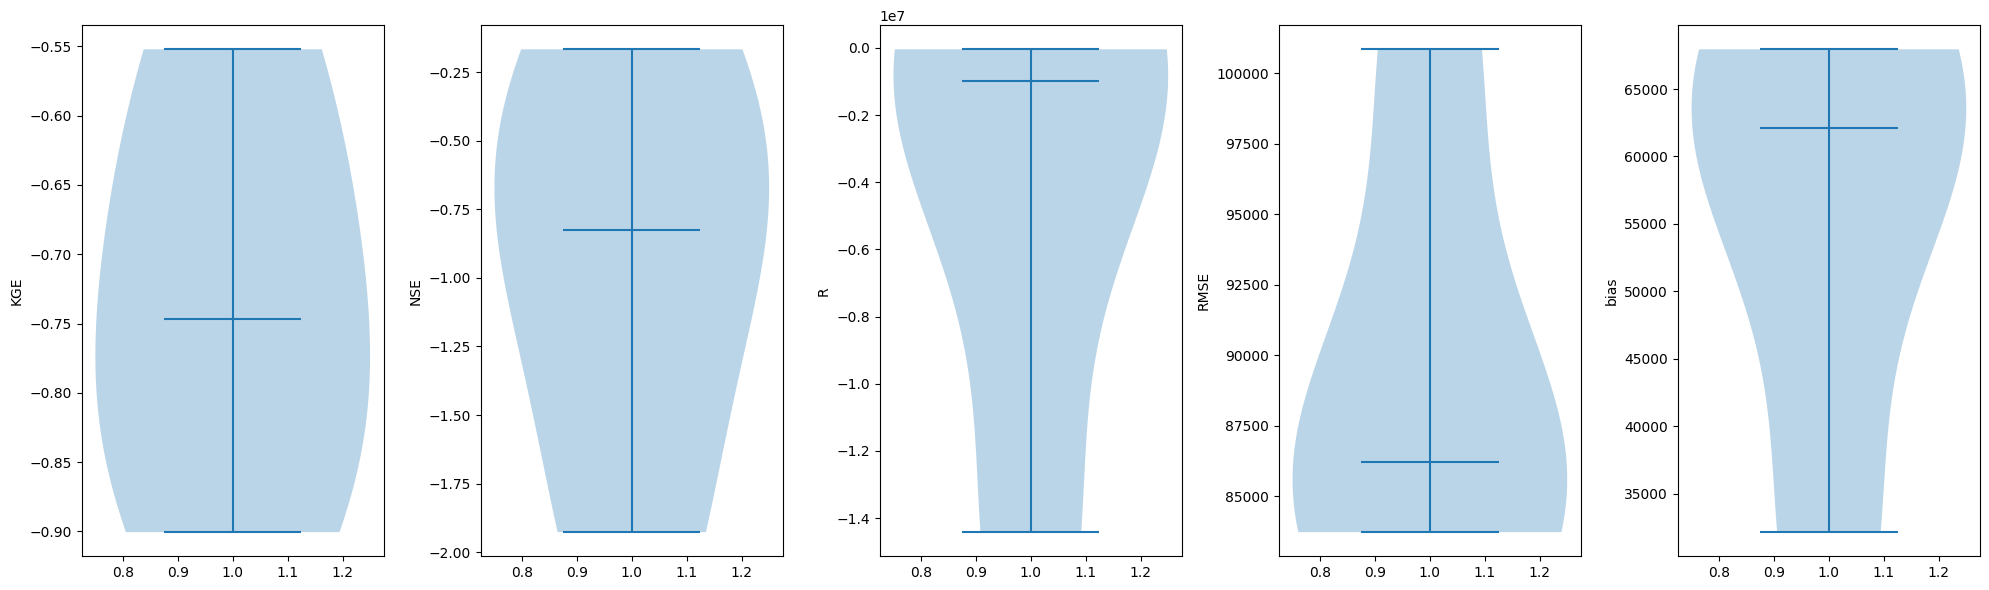

In [45]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(nrows = 1, ncols = 5, figsize = (20, 6))
ax1.violinplot(validation_fe_tot["KGE"], showmedians = True)
ax1.set_ylabel("KGE")
ax2.violinplot(validation_fe_tot["NSE"], showmedians = True)
ax2.set_ylabel("NSE")
ax3.violinplot(validation_fe_tot["R"], showmedians = True)
ax3.set_ylabel("R")
ax4.violinplot(validation_fe_tot["RMSE"], showmedians = True)
ax4.set_ylabel("RMSE")
ax5.violinplot(validation_fe_tot["bias"], showmedians = True)
ax5.set_ylabel("bias")
plt.tight_layout();

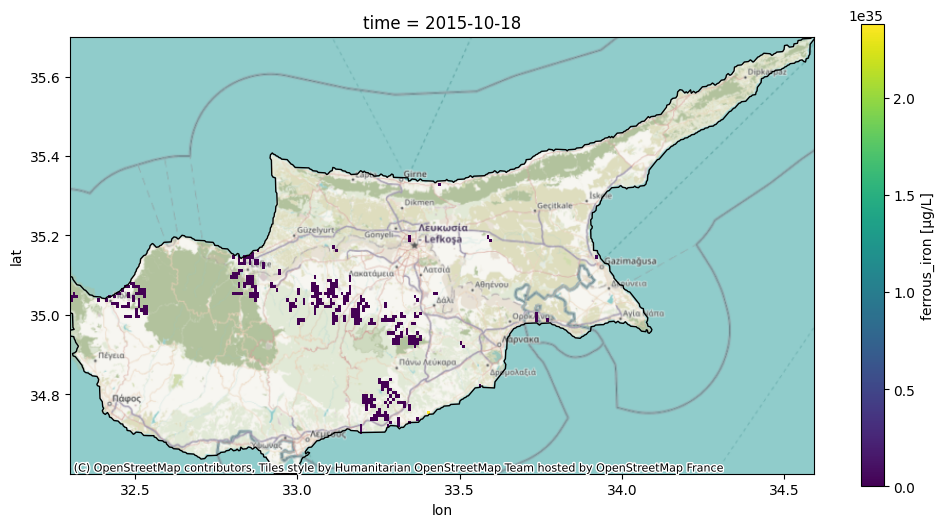

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
ferrous_iron.where(ferrous_iron > 0).isel(time = [-1]).plot(ax = ax)
aoi.plot(ax = ax,facecolor="None",  edgecolor= "k")
cx.add_basemap(ax, crs = aoi.crs)



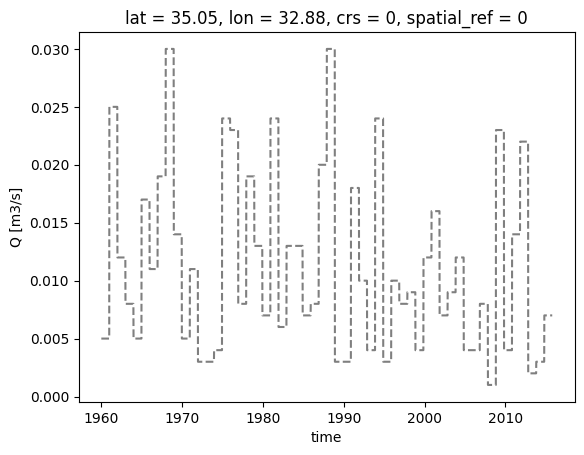

In [47]:
model.dataset["Q"].sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"], method = "nearest").plot(linestyle = "--", color = "k", alpha = 0.5)

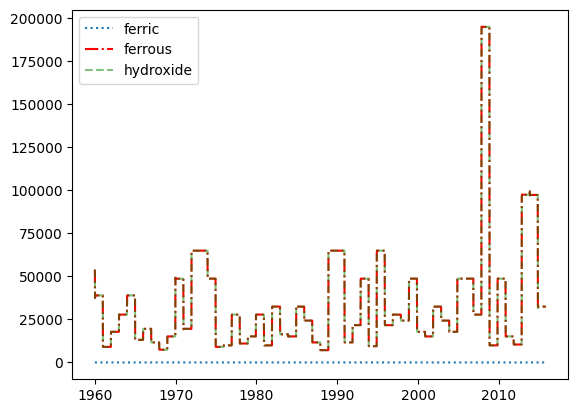

In [48]:
ferric_best = ferric_iron.sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"])
ferrous_best = ferrous_iron.sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"])
hydroxide_best = iron_III_hydroxide.sel(lat = best_nse_fe_tot["cell_lat"], lon = best_nse_fe_tot["cell_lon"])

fig, ax = plt.subplots()

ax.plot(ferric_best.time, ferric_best.values, label = "ferric", linestyle = ":")
ax.plot(ferrous_best.time, ferrous_best.values + ferric_best, label = "ferrous", color = "r", linestyle = "-.")
ax.plot(hydroxide_best.time, hydroxide_best.values + ferric_best + ferrous_best, label = "hydroxide", color = "g", linestyle = "--", alpha = 0.5)
plt.legend()

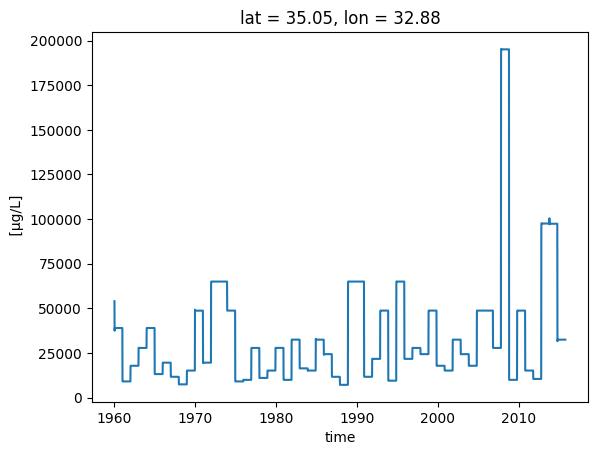

In [49]:
model_fe_tot.plot(label = "Modeled Fe-Tot")

In [50]:
arr = ph.values
clean_arr = arr[np.isfinite(arr)]
lowest = clean_arr.min() if len(clean_arr) > 0 else np.nan
print(lowest)

-35.58532
